In [2]:
#IMPORTANT! Set your working directory here, its supposed to be the MOFA directory in the project
%cd D:\Uni\Master\Data Science\Project\Code_local\MOFA

D:\Uni\Master\Data Science\Project\Code_local\MOFA


In [3]:
##### ONLY RUN THIS BLOCK IF YOU DON'T HAVE THE MODEL
print("This is the older Mofa model training/analysis, that uses the model using all layers without any filtering. I included it here, due to the curiosity of imputing the RPPA layer.")
print("Run this first codeblock ONLY if you don't have the trained model already. The training WILL take multiple hours.")
import os
import numpy as np
import pandas as pd
from mofapy2.run.entry_point import entry_point


file_paths = {
    "RNAseq": os.path.join(os.getcwd(), "..", "TCGA-KIRC/HiSeqV2.txt"),
    "Exon": os.path.join(os.getcwd(), "..", "TCGA-KIRC/HiSeqV2_exon.txt"),
    "Methylation": os.path.join(os.getcwd(), "..", "TCGA-KIRC/HumanMethylation450.txt"),
    "RPPA": os.path.join(os.getcwd(), "..", "TCGA-KIRC/RPPA.txt")#,
    #"CNV": os.path.join(os.getcwd(), "..", "TCGA-KIRC/Gistic2_CopyNumber_Gistic2_all_thresholded_by_genes.txt")
}

loaded_dfs = {}

def process_tcga_file(filepath):
    df = pd.read_csv(filepath, sep="\t", index_col=0)
    
    #Check if samples are columns or rows by matching the TCGA prefix
    columns_are_samples = df.columns.astype(str).str.contains("TCGA-").any()
    rows_are_samples = df.index.astype(str).str.contains("TCGA-").any()
    
    if columns_are_samples:
        df = df.T
    elif not rows_are_samples:
        raise ValueError(f"Could not automatically locate TCGA sample identifiers in {filepath}")
        
    df.index.name = "Sample_ID"
    
    #Clean up duplicate sample rows by averaging numeric values, doesnt really happen with our dataset, but who knows
    df = df.groupby(level=0).mean()
    return df

print("Process and load all five omics layers. you need multiple GB of memory to do this.")
for view_name, path in file_paths.items():
    if os.path.exists(path):
        print(f"Processing layer: {view_name} from {path}...")
        loaded_dfs[view_name] = process_tcga_file(path)
    else:
        print(f"Warning: File {path} not found. Please verify local directory paths.")

#GROUPS AND LAYERS GENERATION FOR MULTI-GROUP MOFA

all_samples = set()
for df in loaded_dfs.values():
    all_samples.update(df.index.tolist())
all_samples = list(all_samples)

print("Map samples into structured condition group categories:")
print("-01 to -09 -> Disease tissue, -11 to -19 -> Adjacent Normal tissue. there are only -01, -05 and -11 in our set, but -05 is a single sample, that is also cancerous, so we just keep it as cancer")
sample_groups = {}
for sample in all_samples:
    suffix = sample.split("-")[-1]
    if suffix.startswith("0"):
        sample_groups[sample] = "Disease"
    elif suffix.startswith("1"):
        sample_groups[sample] = "Normal"
    else:
        sample_groups[sample] = "Other"

# Retain only clear Disease and Normal samples, should be all samples
valid_samples = [s for s in all_samples if sample_groups[s] in ["Disease", "Normal"]]

views_names = list(loaded_dfs.keys())
groups_names = ["Disease", "Normal"]

print(f"\nConfigured Views: {views_names}")
print(f"Configured Groups: {groups_names}")

data = [[None for _ in range(len(groups_names))] for _ in range(len(views_names))]
samples_names = [[] for _ in range(len(groups_names))]

# Create unique suffix tag mapping to prevent feature space overlaps. We havent found any overlaps, but it could happen.
feature_suffixes = {
    "RNAseq": "_rna", 
    "Exon": "_exon", 
    "Methylation": "_meth", 
    "RPPA": "_rppa"#, 
    #"CNV": "_cnv"
}

features_names = []
for view_name in views_names:
    suffix = feature_suffixes.get(view_name, f"_{view_name.lower()}")
    v_features = [f"{feat}{suffix}" for feat in loaded_dfs[view_name].columns]
    features_names.append(v_features)

for g_idx, group_name in enumerate(groups_names):
    group_samples = [s for s in valid_samples if sample_groups[s] == group_name]
    samples_names[g_idx] = group_samples
    
    for v_idx, view_name in enumerate(views_names):
        aligned_df = loaded_dfs[view_name].reindex(group_samples)
        data[v_idx][g_idx] = aligned_df.to_numpy()

print("All 5 multi-omics data layers are structured and ready for MOFA+ training.")

#MOFA+ INITIALIZATION & TRAINING RUN

ent = entry_point()

ent.set_data_options(scale_views=False)

ent.set_data_matrix(
    data,
    views_names=views_names,
    groups_names=groups_names,
    samples_names=samples_names,
    features_names=features_names,
    likelihoods=["gaussian"] * len(views_names),
)

print("We set model training priors here with ARD(Automatic Relevance Determination) weights enabled, meaning it can go lower from our set 15 factors, if the explained variance is too low.")
ent.set_model_options(factors=15, spikeslab_weights=True, ard_weights=True)

ent.set_train_options(
    iter=1000, convergence_mode="fast", dropR2=None, gpu_mode=False, seed=42
)

ent.build()
ent.run()

output_model_name = "mofa_tcga_kirc_5layers_model_no_CNV.hdf5"
ent.save(output_model_name)
print(f"\nModel training finished successfully! Saved as: {output_model_name}")

This is the older Mofa model training/analysis, that uses the model using all layers without any filtering. I included it here, due to the curiosity of imputing the RPPA layer.
Run this first codeblock ONLY if you don't have the trained model already. The training WILL take multiple hours.
Process and load all five omics layers. you need multiple GB of memory to do this.
Processing layer: RNAseq from D:\Uni\Master\Data Science\Project\Code_local\MOFA\..\TCGA-KIRC/HiSeqV2.txt...
Processing layer: Exon from D:\Uni\Master\Data Science\Project\Code_local\MOFA\..\TCGA-KIRC/HiSeqV2_exon.txt...
Processing layer: Methylation from D:\Uni\Master\Data Science\Project\Code_local\MOFA\..\TCGA-KIRC/HumanMethylation450.txt...
Processing layer: RPPA from D:\Uni\Master\Data Science\Project\Code_local\MOFA\..\TCGA-KIRC/RPPA.txt...
Map samples into structured condition group categories:
-01 to -09 -> Disease tissue, -11 to -19 -> Adjacent Normal tissue. there are only -01, -05 and -11 in our set, but -05

In [5]:
print("Get the explained variance of each cohort per factor across all views.")
import h5py
import numpy as np

outfile = "mofa_tcga_kirc_5layers_model_no_CNV.hdf5"
f = h5py.File(outfile, "r")

available_groups = ["Disease", "Normal"]
available_views = ["Methylation", "RNAseq","RPPA","Exon"]

print("=== MOFA2 EXPLAINED VARIANCE ANALYSIS ===")

for group in available_groups:
    total_matrix = f["variance_explained"]["r2_total"][group][:]
    factor_matrix = f["variance_explained"]["r2_per_factor"][group][:]

    print(f"\n=========================================\nDIAGNOSIS GROUP: {group.upper()}\n=========================================")
    
    for view_idx, view_name in enumerate(available_views):
        raw_total = total_matrix[view_idx]
        raw_factors = factor_matrix[view_idx, :]
        raw_factors = np.clip(raw_factors, 0, None)
        if raw_total <= 1.0 and np.max(raw_factors) <= 1.0:
            total_pct = raw_total * 100
            factors_pct = raw_factors * 100
        else:
            total_pct = raw_total
            factors_pct = raw_factors
        
        print(f"\n🔹 Modality: {view_name} (Total Variance Explained: {total_pct:.2f}%)")
        print(f"  {'Factor':12} | {'True Contribution to Modality':35}")
        print(f"  {'-'*12}-+-{'-'*35}")
        
        for factor_idx, final_r2 in enumerate(factors_pct):
            print(f"  Factor {factor_idx + 1:<4}     | {final_r2:.2f}%")

f.close()

Get the explained variance of each cohort per factor across all views.
=== MOFA2 EXPLAINED VARIANCE ANALYSIS ===

DIAGNOSIS GROUP: DISEASE

🔹 Modality: Methylation (Total Variance Explained: 43.91%)
  Factor       | True Contribution to Modality      
  -------------+------------------------------------
  Factor 1        | 5.81%
  Factor 2        | 5.29%
  Factor 3        | 6.18%
  Factor 4        | 1.64%
  Factor 5        | 3.07%
  Factor 6        | 4.46%
  Factor 7        | 4.74%
  Factor 8        | 0.94%
  Factor 9        | 2.88%
  Factor 10       | 2.41%
  Factor 11       | 1.20%
  Factor 12       | 0.60%
  Factor 13       | 0.99%
  Factor 14       | 3.26%
  Factor 15       | 0.73%

🔹 Modality: RNAseq (Total Variance Explained: 63.10%)
  Factor       | True Contribution to Modality      
  -------------+------------------------------------
  Factor 1        | 4.17%
  Factor 2        | 31.32%
  Factor 3        | 4.15%
  Factor 4        | 0.85%
  Factor 5        | 1.72%
  Factor 6   

In [6]:
import h5py
import numpy as np
import pandas as pd

outfile = "mofa_tcga_kirc_5layers_model_no_CNV.hdf5"
f = h5py.File(outfile, "r")

rna_features = [x.decode("utf-8") for x in f["features"]["RNAseq"][:]]
meth_features = [x.decode("utf-8") for x in f["features"]["Methylation"][:]]

weights_rna = f["expectations"]["W"]["RNAseq"][:].T
weights_meth = f["expectations"]["W"]["Methylation"][:].T

df_rna_weights = pd.DataFrame(weights_rna, index=rna_features)
df_meth_weights = pd.DataFrame(weights_meth, index=meth_features)


#function to print out the top drivers for a specific factor
def get_top_drivers(factor_number, top_n=10):
    f_idx = factor_number - 1

    print(
        f"\n======================================================\nTOP DRIVERS FOR FACTOR {factor_number}\n======================================================"
    )

    top_rna = df_rna_weights[f_idx].reindex(
        df_rna_weights[f_idx].abs().sort_values(ascending=False).index
    )
    print(f"\n🧬 Top {top_n} Driving Genes (RNAseq):")
    print(f"  {'Gene Name':20} | {'Weight Value':12}")
    print(f"  {'-'*20}-+-{'-'*12}")
    for gene, val in top_rna.head(top_n).items():
        print(f"  {gene:20} | {val:+.4f}")

    top_meth = df_meth_weights[f_idx].reindex(
        df_meth_weights[f_idx].abs().sort_values(ascending=False).index
    )
    print(f"\n🔹 Top {top_n} Driving Peaks (Methylation):")
    print(f"  {'Peak ID':20} | {'Weight Value':12}")
    print(f"  {'-'*20}-+-{'-'*12}")
    for peak, val in top_meth.head(top_n).items():
        print(f"  {peak:20} | {val:+.4f}")


get_top_drivers(factor_number=1, top_n=10)
get_top_drivers(factor_number=2, top_n=10)
get_top_drivers(factor_number=3, top_n=10)
get_top_drivers(factor_number=4, top_n=10)
get_top_drivers(factor_number=5, top_n=10)
get_top_drivers(factor_number=6, top_n=10)
get_top_drivers(factor_number=7, top_n=10)
get_top_drivers(factor_number=8, top_n=10)
get_top_drivers(factor_number=9, top_n=10)
get_top_drivers(factor_number=10, top_n=10)
f.close()


TOP DRIVERS FOR FACTOR 1

🧬 Top 10 Driving Genes (RNAseq):
  Gene Name            | Weight Value
  ---------------------+-------------
  SLC22A6_rna          | +1.0956
  ACSM2B_rna           | +1.0342
  SLC17A3_rna          | +1.0151
  SLC5A12_rna          | +1.0038
  AGXT2_rna            | +1.0032
  NAT8_rna             | +0.9978
  SLC22A12_rna         | +0.9936
  PRODH2_rna           | +0.9867
  CYP4A11_rna          | +0.9780
  ACSM2A_rna           | +0.9712

🔹 Top 10 Driving Peaks (Methylation):
  Peak ID              | Weight Value
  ---------------------+-------------
  cg10790704_meth      | -0.0782
  cg16233472_meth      | -0.0768
  cg21201401_meth      | -0.0741
  cg14143304_meth      | +0.0728
  cg14546128_meth      | +0.0710
  cg04428071_meth      | -0.0699
  cg10533161_meth      | +0.0694
  cg10092251_meth      | -0.0672
  cg26530045_meth      | -0.0669
  cg26386472_meth      | +0.0668

TOP DRIVERS FOR FACTOR 2

🧬 Top 10 Driving Genes (RNAseq):
  Gene Name            | Weig

In [7]:
print("Here we perform multiple statistical tests to see the relevant associations between the MOFA factors and the clinical/phenotype data.")
import os
import h5py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr
from lifelines import CoxPHFitter

model_filename = "mofa_tcga_kirc_5layers_model_no_CNV.hdf5"

if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Could not find '{model_filename}'")

print(f"Opening trained MOFA model from {model_filename} via h5py...")

factor_dfs = []

with h5py.File(model_filename, 'r') as f:
    groups_names = list(f['expectations/Z'].keys())
    
    for group_name in groups_names:
        factors = f[f'expectations/Z/{group_name}'][()].T
        raw_samples = f[f'samples/{group_name}'][()]
        samples = [s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in raw_samples]
        col_names = [f"Factor_{i+1}" for i in range(factors.shape[1])]
        g_df = pd.DataFrame(factors, index=samples, columns=col_names)
        factor_dfs.append(g_df)

mofa_factors_df = pd.concat(factor_dfs)
print(f"Extracted a matrix of {mofa_factors_df.shape[0]} samples across {mofa_factors_df.shape[1]} factors.")


print("Loading clinical and survival metadata tables...")
clin_df = pd.read_csv(os.path.join(os.getcwd(), "..", "TCGA-KIRC/KIRC_clinicalMatrix.txt"), sep="\t", index_col=0)
survival_df = pd.read_csv(os.path.join(os.getcwd(), "..", "TCGA-KIRC/KIRC_survival.txt"), sep="\t", index_col=0)

clinical_cols = ['age_at_initial_pathologic_diagnosis', 'gender', 'pathologic_stage', 'neoplasm_histologic_grade']
survival_cols = ['OS', 'OS.time']

clin_sub = clin_df[clinical_cols].copy()
survival_sub = survival_df[survival_cols].copy()

full_pheno_df = clin_sub.merge(survival_sub, left_index=True, right_index=True, how='inner')

print("We use the sample indices to find the matching samples.")
merged_data = mofa_factors_df.merge(full_pheno_df, left_index=True, right_index=True, how='inner')
print(f"Successfully matched complete clinical profiles for {len(merged_data)} samples.\n")



#RUN STATISTICAL ASSOCIATIONS
print("These Matrices are using the significance cutoff of p<0.05, meaning it wasn't corrected for multiple testing. Since we have 15 factors, the cutoff should be 0.05/15 for significant FDR values, meaning it would be 3.33e-03 values instead as a cutoff")

# 1. Spearman Correlation with Age
print("--- Spearman Correlation with Patient Age ---")
for col in mofa_factors_df.columns:
    valid = merged_data[[col, 'age_at_initial_pathologic_diagnosis']].dropna()
    if len(valid) > 10:
        rho, pval = spearmanr(valid[col], valid['age_at_initial_pathologic_diagnosis'])
        if pval < 0.05:
            print(f"  * {col} is significantly associated with Age! (Rho: {rho:.3f}, p-val: {pval:.4e})")

# 2. Kruskal-Wallis across Pathologic Tumor Stages
print("\n--- Kruskal-Wallis Test across Pathologic Stages ---")
for col in mofa_factors_df.columns:
    stage_sub = merged_data[[col, 'pathologic_stage']].dropna()
    stages = stage_sub['pathologic_stage'].unique()
    groups_data = [stage_sub[stage_sub['pathologic_stage'] == st][col].values for st in stages]
    groups_data = [g for g in groups_data if len(g) > 5]
    if len(groups_data) > 1:
        stat, pval = kruskal(*groups_data)
        if pval < 0.05:
            print(f"  * {col} significantly separates Tumor Stages! (p-val: {pval:.4e})")

# 3. Kruskal-Wallis across Histologic Grades
print("\n--- Kruskal-Wallis Test across Histologic Grades (G1-G4) ---")
for col in mofa_factors_df.columns:
    grade_sub = merged_data[[col, 'neoplasm_histologic_grade']].dropna()
    grades = grade_sub['neoplasm_histologic_grade'].unique()
    groups_data = [grade_sub[grade_sub['neoplasm_histologic_grade'] == gd][col].values for gd in grades]
    groups_data = [g for g in groups_data if len(g) > 5]
    if len(groups_data) > 1:
        stat, pval = kruskal(*groups_data)
        if pval < 0.05:
            print(f"  * {col} significantly separates Histologic Grades! (p-val: {pval:.4e})")

# 4. Cox Proportional Hazards Regression for Overall Survival (OS)
print("\n--- Cox Proportional Hazards Regression for Overall Survival ---")
print("We only keep samples that contain survival timelines. all censored samples are excluded. With more time, a proper handling of the censored data could be included.")

survival_fields = ['OS', 'OS.time']
factor_cols = list(mofa_factors_df.columns)

# Drop any row lacking complete survival timelines
cox_data = merged_data[factor_cols + survival_fields].dropna()

# Timeline entries have to be greater than zero to satisfy log calculations in the Cox solver
cox_data = cox_data[cox_data['OS.time'] > 0]

cph = CoxPHFitter()
cph.fit(cox_data, duration_col='OS.time', event_col='OS')
summary_df = cph.summary

# We filter out the factors that show strong predictive value (p < 0.05)
significant_survival_factors = summary_df[summary_df['p'] < 0.05]

if not significant_survival_factors.empty:
    for factor_name, row in significant_survival_factors.iterrows():
        print(f"  * {factor_name} is a SIGNIFICANT predictor of Overall Survival!")
        print(f"    -> Hazard Ratio (exp(coef)): {row['exp(coef)']:.3f} | p-value: {row['p']:.4e}")
else:
    print("  No individual factors met the statistical p < 0.05 threshold for Overall Survival.")
print("\n=== Full Cox Model Summary Matrix ===")
print(summary_df[['coef', 'exp(coef)', 'p', 'z']])

Here we perform multiple statistical tests to see the relevant associations between the MOFA factors and the clinical/phenotype data.
Opening trained MOFA model from mofa_tcga_kirc_5layers_model_no_CNV.hdf5 via h5py...
Extracted a matrix of 745 samples across 15 factors.
Loading clinical and survival metadata tables...
We use the sample indices to find the matching samples.
Successfully matched complete clinical profiles for 744 samples.

These Matrices are using the significance cutoff of p<0.05, meaning it wasn't corrected for multiple testing. Since we have 15 factors, the cutoff should be 0.05/15 for significant FDR values, meaning it would be 3.33e-03 values instead as a cutoff
--- Spearman Correlation with Patient Age ---
  * Factor_2 is significantly associated with Age! (Rho: -0.135, p-val: 2.2930e-04)
  * Factor_5 is significantly associated with Age! (Rho: 0.177, p-val: 1.1757e-06)
  * Factor_7 is significantly associated with Age! (Rho: 0.103, p-val: 4.8544e-03)
  * Factor_8

In [5]:
print("This code extracted the top 100 Features per factor for annotation (Rmd script) and ML input. However, since we use the filtered model, you can ignore this.)")
import os
import h5py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Beginning Top 100 Feature Extraction per Factor ---")
output_csv = "data/mofa_top_100_features_per_factor_no_cnv.csv"
all_exported_features = []
model_filename="mofa_tcga_kirc_5layers_model_no_cnv.hdf5"
with h5py.File(model_filename, 'r') as f:
    views_names = list(f['expectations/W'].keys())
    
    for view_name in views_names:
        W_matrix = f[f'expectations/W/{view_name}'][()]
        raw_features = f[f'features/{view_name}'][()]
        features = [feat.decode('utf-8') if isinstance(feat, bytes) else str(feat) for feat in raw_features]
        
        num_factors = W_matrix.shape[0]
        
        for factor_idx in range(num_factors):
            factor_weights = W_matrix[factor_idx, :]
            abs_weights = np.abs(factor_weights)
            top_100_indices = np.argsort(abs_weights)[-100:][::-1]
            
            for rank, idx in enumerate(top_100_indices):
                all_exported_features.append({
                    "Factor": f"Factor_{factor_idx + 1}",
                    "View": view_name,
                    "Feature_Name": features[idx],
                    "Raw_Weight": factor_weights[idx],
                    "Absolute_Weight": abs_weights[idx],
                    "Rank": rank + 1
                })

export_df = pd.DataFrame(all_exported_features)
export_df.to_csv(output_csv, index=False)
print(f"Successfully generated and saved registry file to: {output_csv}")


This code extracted the top 100 Features per factor for annotation (Rmd script) and ML input. However, since we use the filtered model, you can ignore this.)

--- Beginning Top 100 Feature Extraction per Factor ---
Successfully generated and saved registry file to: data/mofa_top_100_features_per_factor_all_data.csv


In [6]:
print("This codeblock generates plots of the variance explanation of the cohorts by the factors per view.")
import os
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_filename = "mofa_tcga_kirc_5layers_model_no_cnv.hdf5"
available_groups = ["Disease", "Normal"]
available_views = ["Methylation", "RNAseq", "RPPA","Exon"]
output_directory = "mofa_plots"

os.makedirs(output_directory, exist_ok=True)

if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Could not find trained MOFA model snapshot: '{model_filename}'")

sns.set_theme(style="whitegrid", context="talk")

#PLOT INDEPENDENTLY PER GROUP & MODALITY


with h5py.File(model_filename, "r") as f:
    for group in available_groups:
        total_matrix = f["variance_explained"]["r2_total"][group][:]
        factor_matrix = f["variance_explained"]["r2_per_factor"][group][:]

        for view_idx, view_name in enumerate(available_views):
            raw_total = total_matrix[view_idx]
            raw_factors = factor_matrix[view_idx, :]
            raw_factors = np.clip(raw_factors, 0, None)
            
            if raw_total <= 1.0 and np.max(raw_factors) <= 1.0:
                total_pct = raw_total * 100
                factors_pct = raw_factors * 100
            else:
                total_pct = raw_total
                factors_pct = raw_factors

            current_records = []
            for factor_idx, final_r2 in enumerate(factors_pct):
                current_records.append({
                    "Factor": f"Factor {factor_idx + 1}",
                    "Variance_Explained": final_r2
                })
            df_plot = pd.DataFrame(current_records)

            plt.figure(figsize=(10, 5))
            
            ax = sns.barplot(
                data=df_plot,
                x="Factor",
                y="Variance_Explained",
                hue="Factor",
                palette="viridis",
                dodge=False,
                legend=False
            )

            plt.ylabel("Variance Explained (%)", fontweight="bold", fontsize=14)
            plt.xlabel("")
            plt.title(
                f"Cohort: {group.upper()} | Modality: {view_name}\n"
                f"(Total Modality Variance Explained: {total_pct:.2f}%)", 
                fontsize=15, 
                fontweight="bold", 
                pad=15
            )
            
            plt.xticks(rotation=45, ha='right', fontsize=11)
            plt.yticks(fontsize=11)

            for p in ax.patches:
                height = p.get_height()
                if height > 0.1:
                    ax.annotate(
                        f'{height:.2f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', 
                        va='center', 
                        xytext=(0, 6), 
                        textcoords='offset points', 
                        fontsize=10, 
                        fontweight="bold"
                    )

            plt.tight_layout()
            
            safe_filename = f"mofa_variance_no_cnv_{group.lower()}_{view_name.lower()}.png"
            full_export_path = os.path.join(output_directory, safe_filename)
            
            plt.savefig(full_export_path, dpi=300, bbox_inches='tight')
            plt.close()
            
            print(f"-> Generated file: {full_export_path}")

print(f"\nAll Plots saved to: '{output_directory}/'")

This codeblock generates plots of the variance explanation of the cohorts by the factors per view.
-> Generated file: mofa_plots\mofa_variance_all_data_disease_methylation.png
-> Generated file: mofa_plots\mofa_variance_all_data_disease_rnaseq.png
-> Generated file: mofa_plots\mofa_variance_all_data_disease_rppa.png
-> Generated file: mofa_plots\mofa_variance_all_data_disease_cnv.png
-> Generated file: mofa_plots\mofa_variance_all_data_disease_exon.png
-> Generated file: mofa_plots\mofa_variance_all_data_normal_methylation.png
-> Generated file: mofa_plots\mofa_variance_all_data_normal_rnaseq.png
-> Generated file: mofa_plots\mofa_variance_all_data_normal_rppa.png
-> Generated file: mofa_plots\mofa_variance_all_data_normal_cnv.png
-> Generated file: mofa_plots\mofa_variance_all_data_normal_exon.png

All Plots saved to: 'mofa_plots/'


This codeblock calculates and plots the significanct associations of Phenotype and clinical data to the latent factors from MOFA. The results are the same as the table significance output further up.
This code uses an older version of the plot than the filtered model.
Opening trained MOFA model from mofa_tcga_kirc_5layers_model_no_cnv.hdf5 via h5py...
Extracted a matrix of 745 samples across 15 factors.
Loading clinical and survival metadata tables...
Successfully matched complete clinical profiles for 744 samples.

Running statistical evaluations and gathering p-values...
The code loops through each factor to extract and store p-values for all 4 tests
Generating scaled significance barplot...


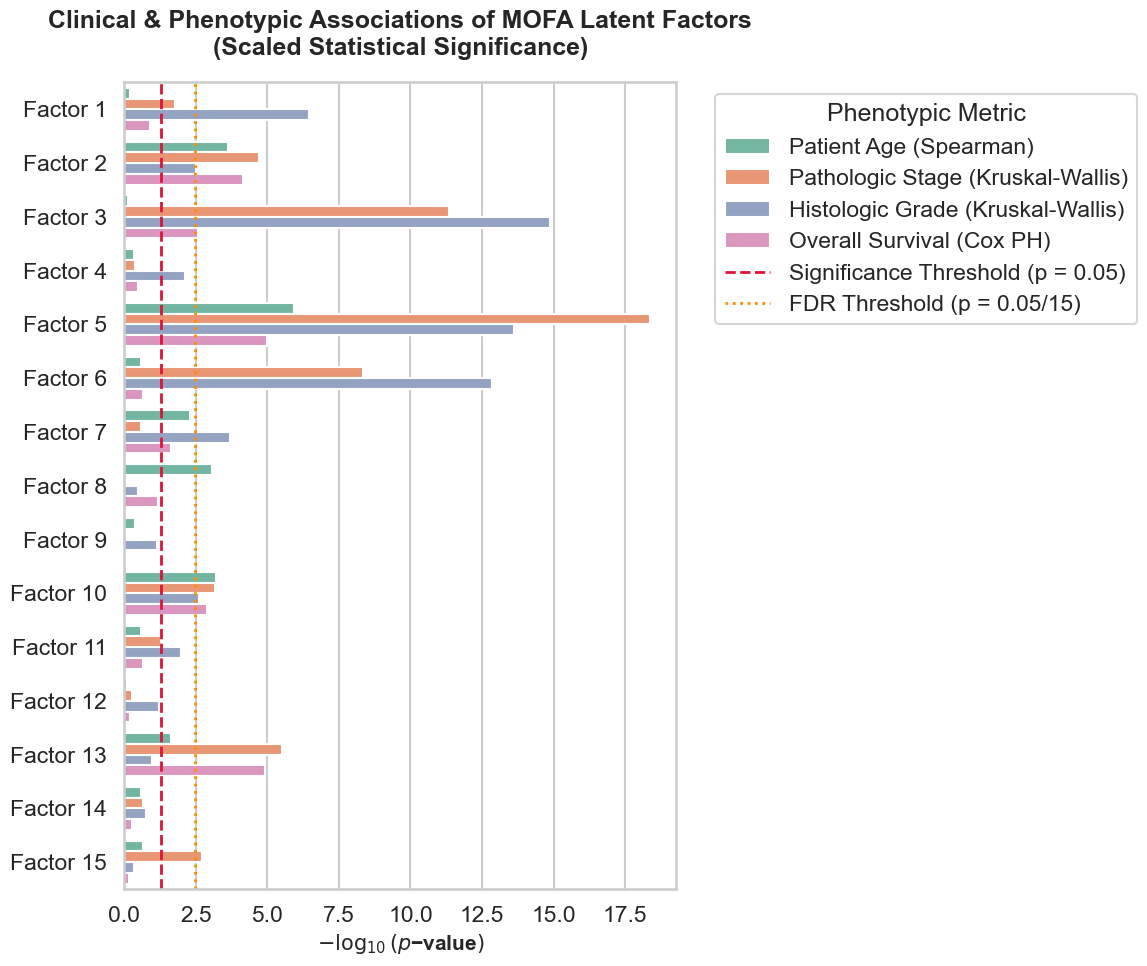

Sideway association plot successfully saved to: mofa_plots/mofa_no_cnv_factors_phenotype_associations.png


In [8]:
print("This codeblock calculates and plots the significanct associations of Phenotype and clinical data to the latent factors from MOFA. The results are the same as the table significance output further up.")
print("This code uses an older version of the plot than the filtered model.")

import os
import h5py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr
from lifelines import CoxPHFitter


model_filename = "mofa_tcga_kirc_5layers_model_no_cnv.hdf5"

if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Could not find '{model_filename}'")

print(f"Opening trained MOFA model from {model_filename} via h5py...")

factor_dfs = []

with h5py.File(model_filename, 'r') as f:
    groups_names = list(f['expectations/Z'].keys())
    
    for group_name in groups_names:
        factors = f[f'expectations/Z/{group_name}'][()].T
        raw_samples = f[f'samples/{group_name}'][()]
        samples = [s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in raw_samples]
        col_names = [f"Factor_{i+1}" for i in range(factors.shape[1])]
        g_df = pd.DataFrame(factors, index=samples, columns=col_names)
        factor_dfs.append(g_df)

mofa_factors_df = pd.concat(factor_dfs)
print(f"Extracted a matrix of {mofa_factors_df.shape[0]} samples across {mofa_factors_df.shape[1]} factors.")

print("Loading clinical and survival metadata tables...")
clin_df = pd.read_csv("D:/Uni/Master/Data Science/Project/TCGA_Kidney/TCGA.KIRC.sampleMap_KIRC_clinicalMatrix.txt", sep="\t", index_col=0)
survival_df = pd.read_csv("D:/Uni/Master/Data Science/Project/TCGA_Kidney/survival_KIRC_survival.txt", sep="\t", index_col=0)

clinical_cols = ['age_at_initial_pathologic_diagnosis', 'gender', 'pathologic_stage', 'neoplasm_histologic_grade']
survival_cols = ['OS', 'OS.time']

clin_sub = clin_df[clinical_cols].copy()
survival_sub = survival_df[survival_cols].copy()

full_pheno_df = clin_sub.merge(survival_sub, left_index=True, right_index=True, how='inner')

merged_data = mofa_factors_df.merge(full_pheno_df, left_index=True, right_index=True, how='inner')
print(f"Successfully matched complete clinical profiles for {len(merged_data)} samples.\n")

#RUN STATISTICAL ASSOCIATIONS & COLLECT P-VALUES

print("Running statistical evaluations and gathering p-values...")
association_records = []

factor_cols = list(mofa_factors_df.columns)
cox_data = merged_data[factor_cols + survival_cols].dropna()
cox_data = cox_data[cox_data['OS.time'] > 0]
cph = CoxPHFitter()
cph.fit(cox_data, duration_col='OS.time', event_col='OS')
cox_summary = cph.summary

print("The code loops through each factor to extract and store p-values for all 4 tests")
for col in factor_cols:
    # 1. Age (Spearman)
    valid_age = merged_data[[col, 'age_at_initial_pathologic_diagnosis']].dropna()
    if len(valid_age) > 10:
        _, p_age = spearmanr(valid_age[col], valid_age['age_at_initial_pathologic_diagnosis'])
    else:
        p_age = 1.0
        
    # 2. Tumor Stage (Kruskal-Wallis)
    stage_sub = merged_data[[col, 'pathologic_stage']].dropna()
    stages = stage_sub['pathologic_stage'].unique()
    stage_groups = [stage_sub[stage_sub['pathologic_stage'] == st][col].values for st in stages]
    stage_groups = [g for g in stage_groups if len(g) > 5]
    p_stage = kruskal(*stage_groups)[1] if len(stage_groups) > 1 else 1.0
    
    # 3. Histologic Grade (Kruskal-Wallis)
    grade_sub = merged_data[[col, 'neoplasm_histologic_grade']].dropna()
    grades = grade_sub['neoplasm_histologic_grade'].unique()
    grade_groups = [grade_sub[grade_sub['neoplasm_histologic_grade'] == gd][col].values for gd in grades]
    grade_groups = [g for g in grade_groups if len(g) > 5]
    p_grade = kruskal(*grade_groups)[1] if len(grade_groups) > 1 else 1.0
    
    # 4. Overall Survival (Cox PH)
    p_survival = cox_summary.loc[col, 'p'] if col in cox_summary.index else 1.0
    
    for test_name, p_val in [
        ("Patient Age (Spearman)", p_age),
        ("Pathologic Stage (Kruskal-Wallis)", p_stage),
        ("Histologic Grade (Kruskal-Wallis)", p_grade),
        ("Overall Survival (Cox PH)", p_survival)
    ]:
        # Clean p-values of 0 to avoid -log10 error
        p_val_clean = max(p_val, 1e-300)
        minus_log_p = -np.log10(p_val_clean)
        
        association_records.append({
            "Factor": col.replace("_", " "),
            "Metadata": test_name,
            "p_value": p_val,
            "Scaled_Significance": minus_log_p
        })

df_assoc = pd.DataFrame(association_records)

#GENERATE THE PLOT

print("Generating scaled significance barplot...")
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 10))

ax = sns.barplot(
    data=df_assoc,
    y="Factor",
    x="Scaled_Significance",
    hue="Metadata",
    palette="Set2",
    orient="h"
)

# Plot significance threshold line (p = 0.05 corresponds to -log10(p) = 1.301)
sig_threshold = -np.log10(0.05)
plt.axvline(
    x=sig_threshold, 
    color="crimson", 
    linestyle="--", 
    linewidth=2, 
    label="Significance Threshold (p = 0.05)"
)
#FWER-line
fdr_p = 0.05 / 15
fdr_threshold = -np.log10(fdr_p)
plt.axvline(
    x=fdr_threshold,
    color="darkorange",
    linestyle=":",
    linewidth=2,
    label="FWER Threshold (p = 0.05/15)"
)

plt.xlabel("$-\log_{10}(p\mathregular{-value})$", fontweight="bold", fontsize=15)
plt.ylabel("", fontweight="bold", fontsize=15)
plt.title(
    "Clinical & Phenotypic Associations of MOFA Latent Factors\n"
    "(Scaled Statistical Significance)", 
    fontsize=18, 
    fontweight="bold", 
    pad=20
)

plt.legend(title="Phenotypic Metric", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()

output_filepath = "mofa_plots/mofa_no_cnv_factors_phenotype_associations.png"
plt.savefig(output_filepath, dpi=300, bbox_inches='tight')
plt.show()

print(f"Sideway association plot successfully saved to: {output_filepath}")